# PROJECT 2: Bike Sharing Demand

### Algorithm: Polynomial Regression

**Problem Statement:**

To predict the number of bikes rented in a bike-sharing system based on temporal, weather, and calendar features using machine learning.



---



Importing the Dependencies

In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib

Data Collection & Processing

In [157]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bike-sharing-dataset' dataset.
Path to dataset files: /kaggle/input/bike-sharing-dataset


In [158]:
# loading the dataset into dataframe
bike_df = pd.read_csv('/kaggle/input/bike-sharing-dataset/hour.csv')

In [159]:
# printing the first 5 rows of the dataframe
bike_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [160]:
# number of rows and columns in the dataframe
bike_df.shape

(17379, 17)

In [161]:
# statical measures
bike_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [162]:
# number of missing values in each columns
bike_df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


EDA

*Target Distribution*

<Axes: xlabel='count', ylabel='Count'>

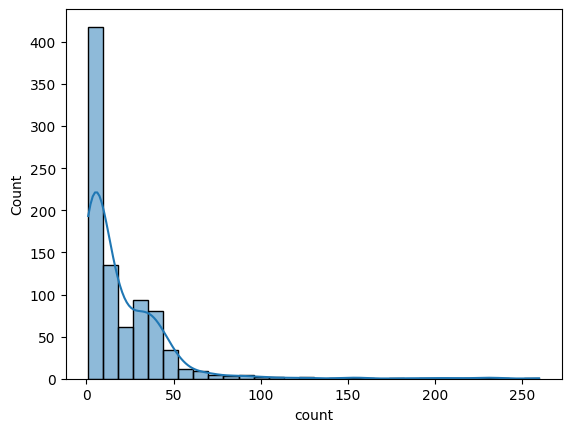

In [163]:
sns.histplot(bike_df['cnt'].value_counts(), bins=30, kde=True)

*Correlation With the Target*

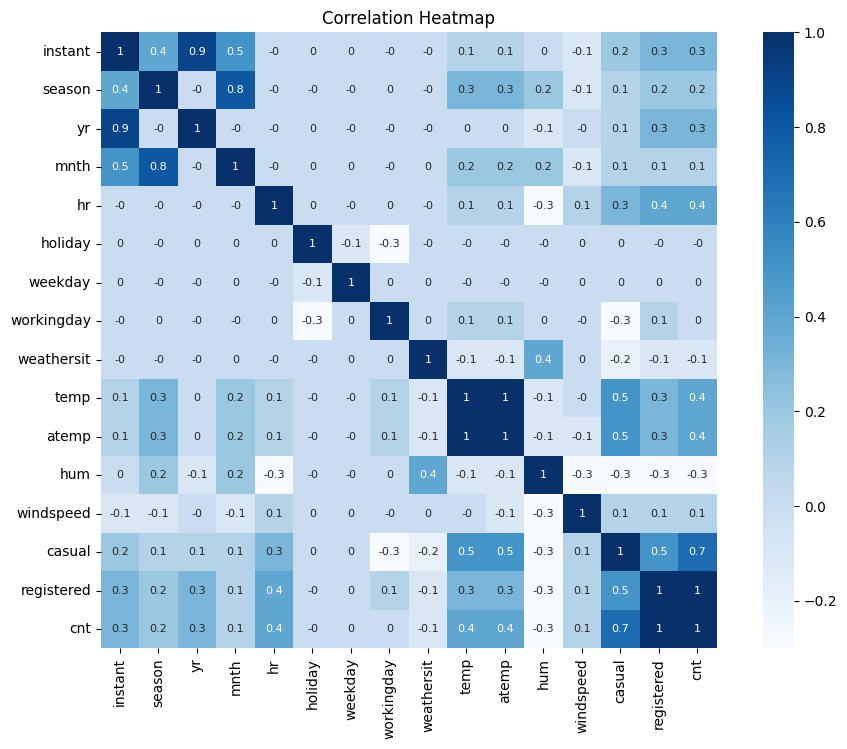

In [164]:
plt.figure(figsize=(12,8))
sns.heatmap(bike_df.corr(numeric_only=True).round(1), cbar=True, square=True, annot_kws={'size':8}, annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

*Features Count by Rentals*

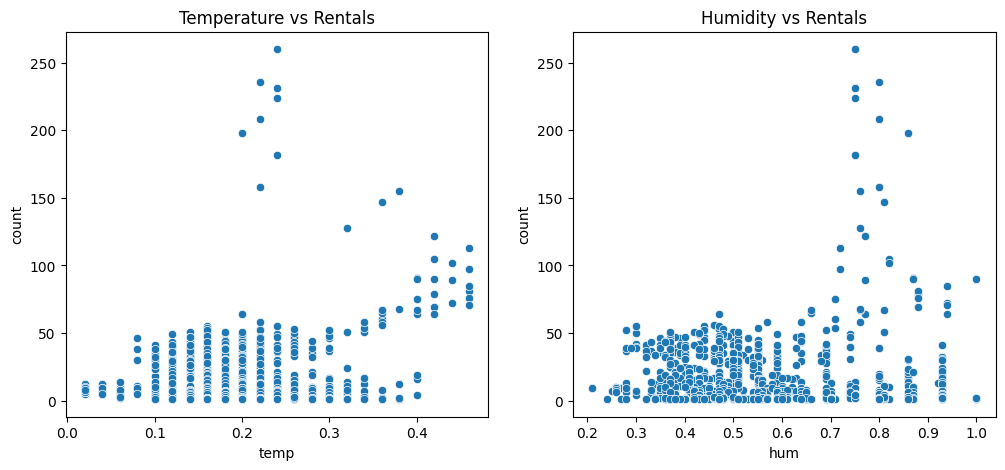

In [165]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x=bike_df['temp'], y=bike_df['cnt'].value_counts())
plt.title("Temperature vs Rentals")

plt.subplot(1,2,2)
sns.scatterplot(x=bike_df['hum'], y=bike_df['cnt'].value_counts())
plt.title("Humidity vs Rentals")

plt.show()

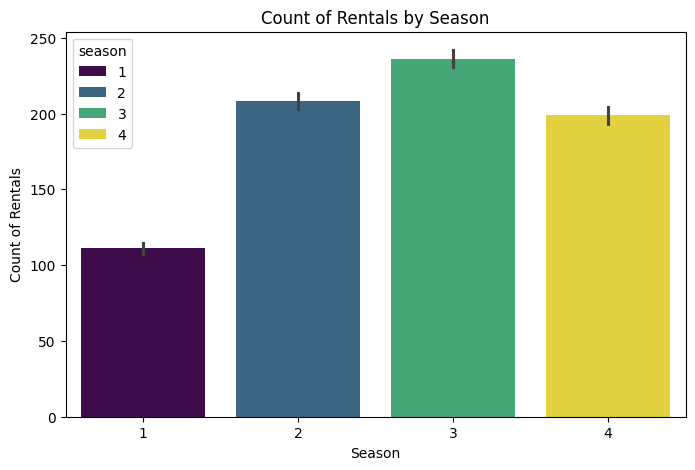

In [166]:
plt.figure(figsize=(8,5))
sns.barplot(x='season', y='cnt', hue='season', data=bike_df, palette='viridis')
plt.title("Count of Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Count of Rentals")
plt.show()

In [167]:
# Since the fall season has the most rentals

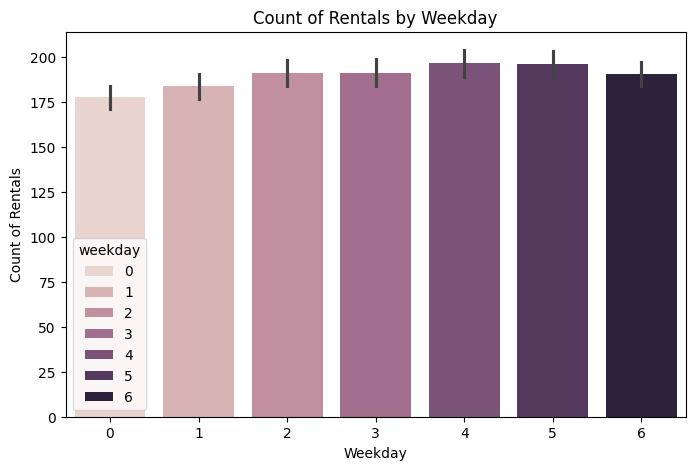

In [168]:
plt.figure(figsize=(8,5))
sns.barplot(x='weekday', y='cnt', hue='weekday', data=bike_df)
plt.title("Count of Rentals by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Count of Rentals")
plt.show()

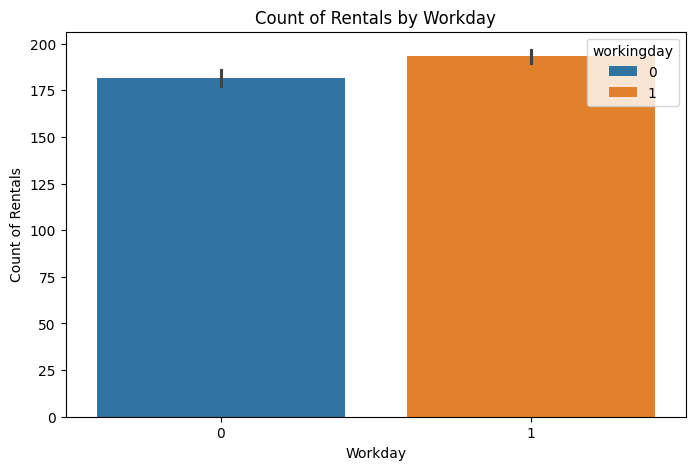

In [169]:
plt.figure(figsize=(8,5))
sns.barplot(x='workingday', y='cnt', hue='workingday', data=bike_df)
plt.title("Count of Rentals by Workday")
plt.xlabel("Workday")
plt.ylabel("Count of Rentals")
plt.show()

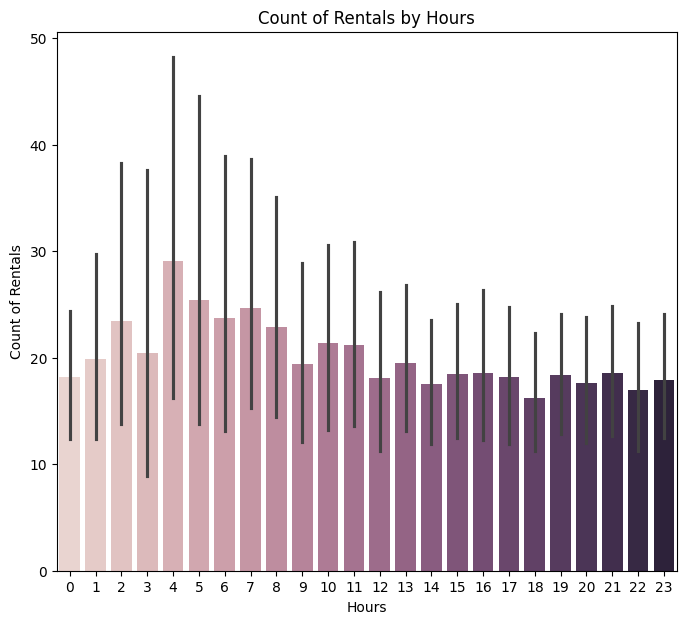

In [170]:
plt.figure(figsize=(8,7))
sns.barplot(x='hr', y=bike_df['cnt'].value_counts(), hue='hr', data=bike_df, legend=None)
plt.title("Count of Rentals by Hours")
plt.xlabel("Hours")
plt.ylabel("Count of Rentals")
plt.show()

Splitting the target & the features

In [171]:
bike_targets = bike_df['cnt']
bike_features = bike_df.drop(columns=['instant','dteday','cnt', 'casual', 'registered'], axis=1)

Identify Feature Types

In [172]:
num_features = bike_features.drop(columns=['season', 'yr', 'mnth', 'hr', 'holiday', 'workingday', 'weathersit'], axis=1).columns.to_list()
cat_features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'workingday', 'weathersit']

Building Preprocessing Pipelines

Categorical Pipeline

In [173]:
cat_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

Combine Pipelines

In [174]:
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_features),
    ('cat', cat_pipeline, cat_features)
])

Full ML pipeline (Preprocessing + Model)

In [230]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('polynomial', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
])

Splitting the Data into training and testing

In [231]:
X_train, X_test, y_train, y_test = train_test_split(bike_features, bike_targets, test_size=0.2, random_state=42)

Fitting the training data into the pipeline

In [232]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['weekday', 'temp', 'atemp',
                                                   'hum', 'windspeed']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['season', 'yr', 'mnth', 'hr',
                                                   'holiday', 'workingday',
                                                   'weathersit'])])),
                ('polynomial', PolynomialFeatures()),
                ('model', LinearRegression())])

Taking Predictions

In [233]:
y_pred = pipeline.predict(X_test)

Model Evaluation

In [234]:
y_train_pred = pipeline.predict(X_train)

# Checking mean absolute error, root mean squared error and r2 score for evaluation
mae = mean_absolute_error(y_train, y_train_pred)
rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2 = r2_score(y_train, y_train_pred)

print("Training data metrics")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Training data metrics
MAE: 34.78250165360671
RMSE: 50.26405860013928
R² Score: 0.9239057494865023


In [235]:
# Checking mean absolute error, root mean squared error and r2 score for evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Testing data metrics")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Testing data metrics
MAE: 36.97609169183158
RMSE: 53.72942338156458
R² Score: 0.9088326721468558


Actual vs Predicted Values

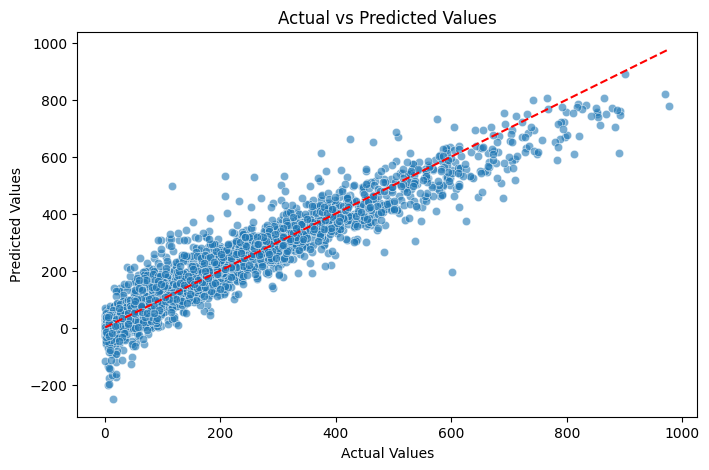

In [236]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

Residue Analysis

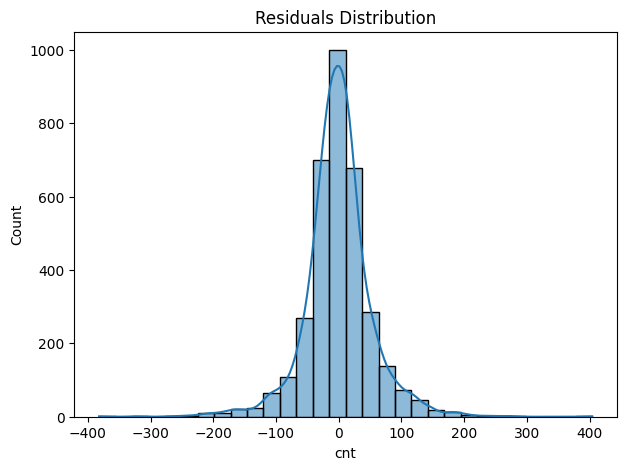

In [237]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
sns.histplot(residuals, kde=True, bins=30)
plt.title("Residuals Distribution")
plt.show()

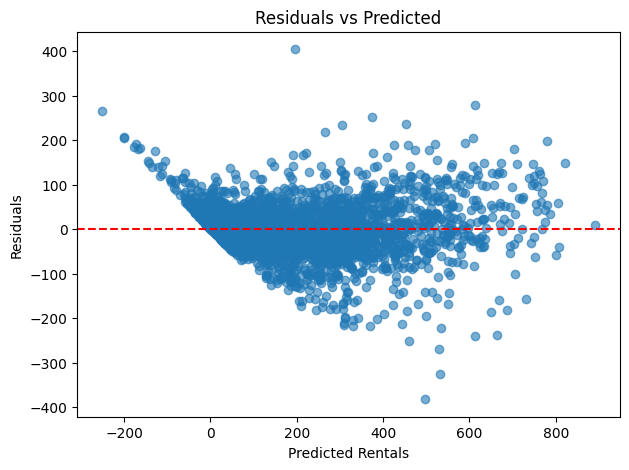

In [238]:
plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Predicted Rentals")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

Saving the Pipeline

In [243]:
joblib.dump(pipeline, 'bike_sharing_prediction.pkl')

['bike_sharing_prediction.pkl']

Loading for New Predictions

In [244]:
bike_features.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0


In [245]:
bike_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [246]:
joblib.load('bike_sharing_prediction.pkl')


new_data = pd.DataFrame({
    'season': ['1'],
    'yr': ['0'],
    'mnth': ['1'],
    'hr': ['0'],
    'holiday': ['0'],
    'weekday': ['6'],
    'workingday': ['0'],
    'weathersit': ['1'],
    'temp': [0.24],
    'atemp': [0.2879],
    'hum': [0.81],
    'windspeed': [0]
})

prediction = pipeline.predict(new_data)
print("Predicted House Price:", prediction[0])

Predicted House Price: 25.017437023984456
